# **Exploratory Data Analysis — Univariate, Bivariate & Multivariate**

## **Upwork Job Market Analysis — End-to-End Data Science Project**

### **Notebook Overview**
This notebook performs a thorough three-layer exploratory analysis on the cleaned Upwork dataset. Each layer progressively reveals richer patterns:

- **Univariate Analysis** — Distributions of individual variables in isolation
- **Bivariate Analysis** — Pairwise relationships between two variables at a time
- **Multivariate Analysis** — Complex interactions across three or more dimensions simultaneously

### **Goals of this Notebook**
1. Understand the distribution of job types, compensation, and geography
2. Reveal how job category and client country drive salary differences
3. Uncover temporal posting patterns (monthly, weekly, hourly)
4. Identify multivariate interactions between category, job type, country, and pay
5. Track remote work signal trends across categories
6. Save all charts to `assets/` for the final PDF report


In [1]:

import os
import logging
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

os.makedirs('../logs', exist_ok=True)
os.makedirs('../assets', exist_ok=True)

logger = logging.getLogger('NB02_EDA')
logger.setLevel(logging.DEBUG)
logger.handlers.clear()

fh = logging.FileHandler('../logs/02_eda.log', mode='w')
fh.setFormatter(logging.Formatter('%(asctime)s | %(levelname)-8s | %(message)s'))
ch = logging.StreamHandler()
ch.setFormatter(logging.Formatter('%(levelname)-8s | %(message)s'))

logger.addHandler(fh)
logger.addHandler(ch)
logger.info("=== Notebook 02 — EDA started ===")

df = pd.read_csv('../data/processed/upwork_clean.csv')
df['published_date'] = pd.to_datetime(df['published_date'], utc=True)
logger.info(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Dataset: {df.shape}")


INFO     | === Notebook 02 — EDA started ===
INFO     | Loaded: 244,827 rows × 17 columns


Dataset: (244827, 17)


---
## **Section A — Univariate Analysis**

In this section we examine:
- Categorical variables: job type, job category, day of week
- Numeric variables: hourly rates, fixed budgets
- Temporal variable: posting volume over time


### **A1 — Job Type Distribution**

We examine the fundamental split between hourly and fixed-price jobs. This split shapes the entire compensation analysis because the two types have completely different pay structures.


INFO     | Job type: {'Hourly': 140936, 'Fixed-Price': 103891}
INFO     | Hourly share: 57.6%


INFO     | Saved: assets/A1_job_type_distribution.png


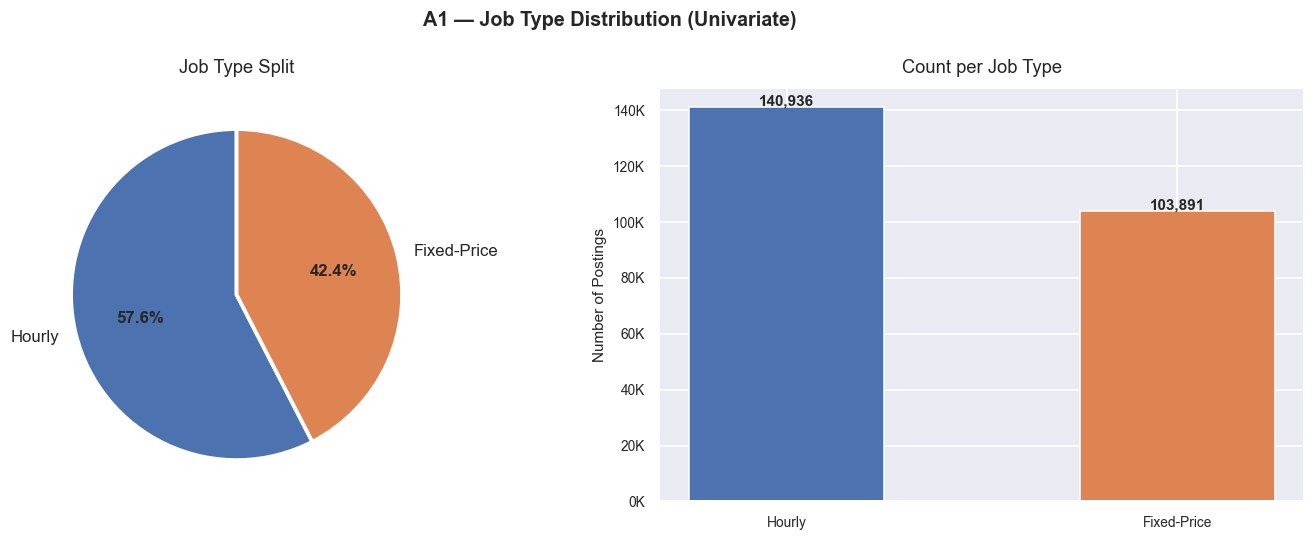

job_type
Hourly         140936
Fixed-Price    103891


In [2]:

type_counts = df['job_type'].value_counts()
logger.info(f"Job type: {type_counts.to_dict()}")
logger.info(f"Hourly share: {type_counts['Hourly'] / len(df) * 100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('A1 — Job Type Distribution (Univariate)', fontweight='bold', fontsize=13)

colors = ['#4C72B0', '#DD8452']
wedges, texts, autotexts = axes[0].pie(
    type_counts.values, labels=type_counts.index,
    autopct='%1.1f%%', colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title('Job Type Split', pad=10)

bars = axes[1].bar(type_counts.index, type_counts.values,
                   color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Count per Job Type', pad=10)
axes[1].set_ylabel('Number of Postings')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, val in zip(bars, type_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 700,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/A1_job_type_distribution.png', bbox_inches='tight')
logger.info("Saved: assets/A1_job_type_distribution.png")
plt.show()
print(type_counts.to_string())


### **A2 — Job Category Distribution**

A horizontal bar chart shows posting volume per category. This tells us which domains dominate Upwork's marketplace and where freelancers face the most competition.


INFO     | Category posting counts:
INFO     |   Other: 117,317 (47.9%)
INFO     |   Web Development: 36,537 (14.9%)
INFO     |   Writing / Content: 21,773 (8.9%)
INFO     |   Marketing / SEO: 19,181 (7.8%)
INFO     |   Graphic Design: 13,795 (5.6%)
INFO     |   Video / Animation: 11,538 (4.7%)
INFO     |   Customer Support: 5,023 (2.1%)
INFO     |   Mobile Development: 4,758 (1.9%)
INFO     |   Data Science / AI: 4,413 (1.8%)
INFO     |   Data Analysis: 3,230 (1.3%)
INFO     |   Finance / Accounting: 3,206 (1.3%)
INFO     |   DevOps / Cloud: 2,283 (0.9%)
INFO     |   Blockchain / Crypto: 1,773 (0.7%)
INFO     | Saved: assets/A2_category_distribution.png


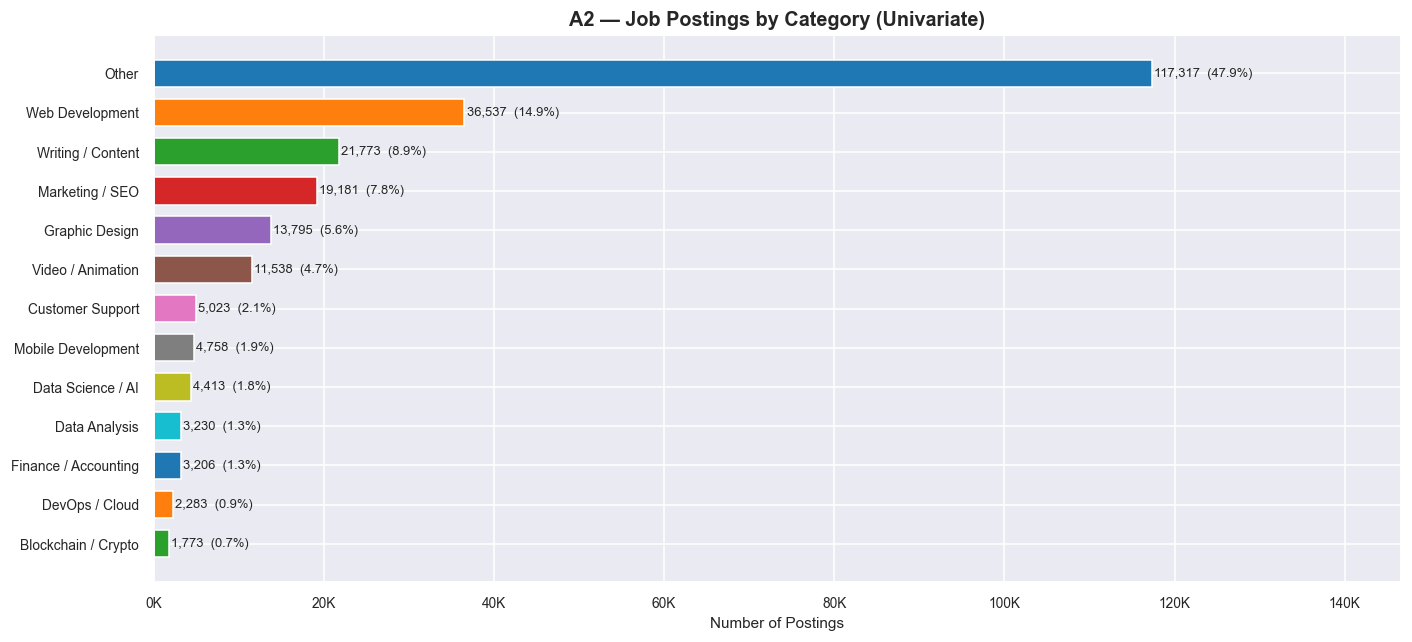

In [3]:

cat_counts = df['category'].value_counts()
logger.info("Category posting counts:")
for cat, cnt in cat_counts.items():
    logger.info(f"  {cat}: {cnt:,} ({cnt / len(df) * 100:.1f}%)")

fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('tab10', n_colors=len(cat_counts))
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1],
               color=palette[::-1], edgecolor='white', height=0.7)
ax.set_title('A2 — Job Postings by Category (Univariate)', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Postings')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar, val in zip(bars, cat_counts.values[::-1]):
    ax.text(val + 250, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({val/len(df)*100:.1f}%)', va='center', fontsize=8.5)
ax.set_xlim(0, cat_counts.max() * 1.25)
plt.tight_layout()
plt.savefig('../assets/A2_category_distribution.png', bbox_inches='tight')
logger.info("Saved: assets/A2_category_distribution.png")
plt.show()


### **A3 — Hourly Rate Distribution**

We examine the `avg_hourly` distribution for the 102K+ hourly jobs using a histogram with KDE overlay and a box plot side-by-side. The right-skewed distribution confirms a small elite earns 10× the median rate.


INFO     | Hourly subset ($3–$200): 102,036 jobs
INFO     |   mean=$28.00 | median=$22.50 | std=$22.96
INFO     | Saved: assets/A3_hourly_rate_distribution.png


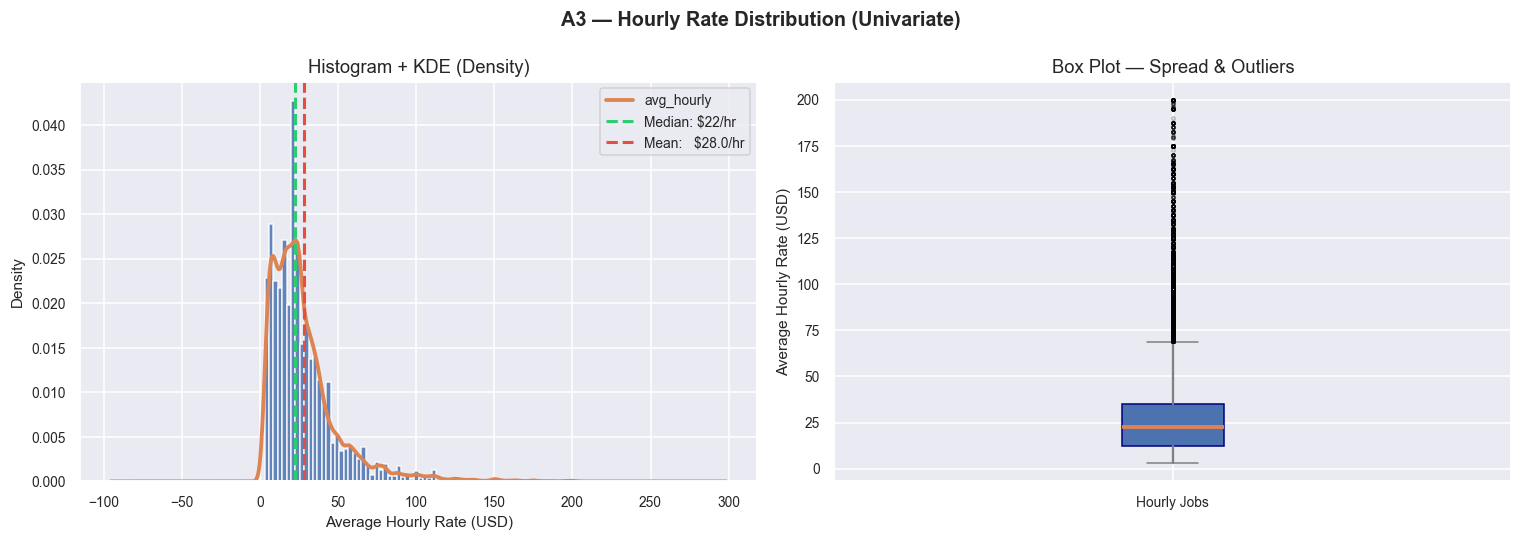

In [4]:

hourly_df = df[df['is_hourly'] & df['avg_hourly'].between(3, 200)].copy()
logger.info(f"Hourly subset ($3–$200): {len(hourly_df):,} jobs")
logger.info(f"  mean=${hourly_df['avg_hourly'].mean():.2f} | "
            f"median=${hourly_df['avg_hourly'].median():.2f} | "
            f"std=${hourly_df['avg_hourly'].std():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('A3 — Hourly Rate Distribution (Univariate)', fontweight='bold', fontsize=13)

# Histogram + KDE
axes[0].hist(hourly_df['avg_hourly'], bins=70, color='#4C72B0',
             edgecolor='white', alpha=0.85, density=True)
hourly_df['avg_hourly'].plot.kde(ax=axes[0], color='#DD8452', linewidth=2.5)
med = hourly_df['avg_hourly'].median()
mn  = hourly_df['avg_hourly'].mean()
axes[0].axvline(med, color='#2ecc71', linewidth=2, linestyle='--',
                label=f'Median: ${med:.0f}/hr')
axes[0].axvline(mn,  color='#e74c3c', linewidth=2, linestyle='--',
                label=f'Mean:   ${mn:.1f}/hr')
axes[0].set_title('Histogram + KDE (Density)')
axes[0].set_xlabel('Average Hourly Rate (USD)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Box plot
bp = axes[1].boxplot(hourly_df['avg_hourly'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', color='navy'),
                medianprops=dict(color='#DD8452', linewidth=2.5),
                whiskerprops=dict(color='grey', linewidth=1.5),
                capprops=dict(color='grey'),
                flierprops=dict(marker='o', color='grey', alpha=0.25, markersize=2))
axes[1].set_title('Box Plot — Spread & Outliers')
axes[1].set_ylabel('Average Hourly Rate (USD)')
axes[1].set_xticklabels(['Hourly Jobs'])

plt.tight_layout()
plt.savefig('../assets/A3_hourly_rate_distribution.png', bbox_inches='tight')
logger.info("Saved: assets/A3_hourly_rate_distribution.png")
plt.show()


### **A4 — Fixed-Price Budget Distribution**

Fixed-price budgets span 5 orders of magnitude ($5 to $1,000,000). We plot both **linear** and **log-scale** x-axes — the log transform reveals a clear 4-mode structure that is completely hidden on the linear scale.


INFO     | Fixed-price subset ($5–$50K): 103,715 jobs
INFO     |   mean=$509 | median=$100
INFO     | Saved: assets/A4_budget_distribution.png


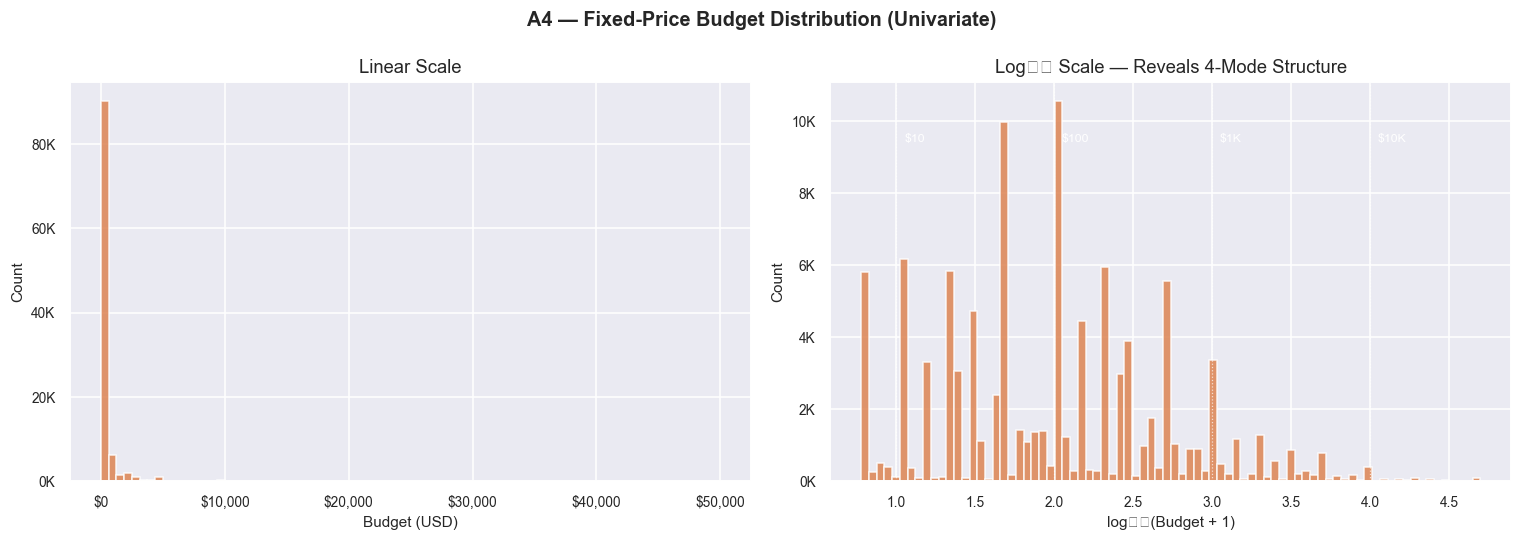

In [5]:

budget_df = df[~df['is_hourly'] & df['budget'].between(5, 50000)].copy()
logger.info(f"Fixed-price subset ($5–$50K): {len(budget_df):,} jobs")
logger.info(f"  mean=${budget_df['budget'].mean():.0f} | median=${budget_df['budget'].median():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('A4 — Fixed-Price Budget Distribution (Univariate)', fontweight='bold', fontsize=13)

axes[0].hist(budget_df['budget'], bins=80, color='#DD8452', edgecolor='white', alpha=0.85)
axes[0].set_title('Linear Scale')
axes[0].set_xlabel('Budget (USD)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

axes[1].hist(np.log10(budget_df['budget'] + 1), bins=80,
             color='#DD8452', edgecolor='white', alpha=0.85)
axes[1].set_title('Log₁₀ Scale — Reveals 4-Mode Structure')
axes[1].set_xlabel('log₁₀(Budget + 1)')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for val, label in [(1, '$10'), (2, '$100'), (3, '$1K'), (4, '$10K')]:
    axes[1].axvline(val, color='white', linewidth=0.8, linestyle=':', alpha=0.7)
    axes[1].text(val + 0.05, axes[1].get_ylim()[1]*0.85, label, color='white', fontsize=8)

plt.tight_layout()
plt.savefig('../assets/A4_budget_distribution.png', bbox_inches='tight')
logger.info("Saved: assets/A4_budget_distribution.png")
plt.show()


### **A5 — Temporal Posting Patterns**

We examine posting volume across months and days of the week. These temporal patterns help freelancers time their proposals and reveal seasonal or calendar-driven shifts.


INFO     | Peak month: 2024-03
INFO     | Peak day:   Wednesday (41,366)
INFO     | Saved: assets/A5_temporal_patterns.png


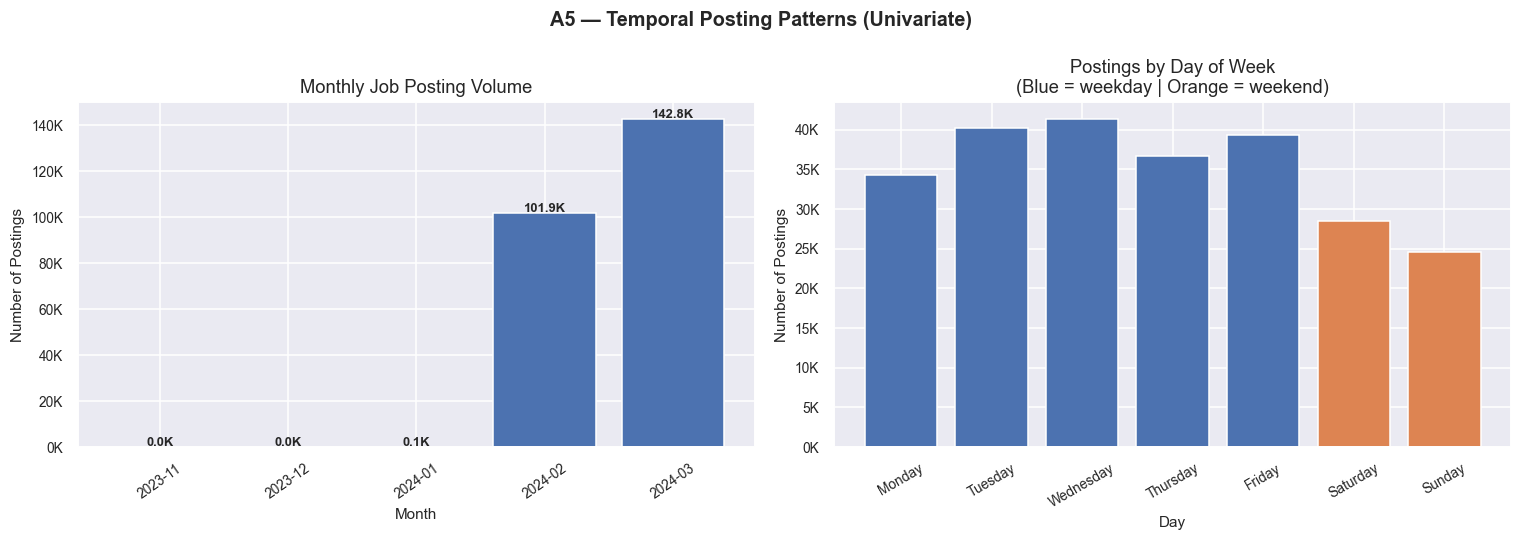

In [6]:
monthly = df.groupby('year_month').size().reset_index(name='count')
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df.groupby('day_of_week').size().reindex(dow_order)

logger.info(f"Peak month: {monthly.loc[monthly['count'].idxmax(), 'year_month']}")
logger.info(f"Peak day:   {dow_counts.idxmax()} ({dow_counts.max():,})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('A5 — Temporal Posting Patterns (Univariate)', fontweight='bold', fontsize=13)

axes[0].bar(monthly['year_month'], monthly['count'], color='#4C72B0', edgecolor='white')
axes[0].set_title('Monthly Job Posting Volume')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Postings')
axes[0].tick_params(axis='x', rotation=35)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for i, (_, row) in enumerate(monthly.iterrows()):
    axes[0].text(i, row['count'] + 350, f"{row['count']/1000:.1f}K",
                 ha='center', fontsize=8.5, fontweight='bold')

dow_colors = ['#4C72B0' if d not in ['Saturday','Sunday'] else '#DD8452' for d in dow_order]
bars = axes[1].bar(dow_order, dow_counts.values, color=dow_colors, edgecolor='white')
axes[1].set_title('Postings by Day of Week\n(Blue = weekday | Orange = weekend)')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Postings')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('../assets/A5_temporal_patterns.png', bbox_inches='tight')
logger.info("Saved: assets/A5_temporal_patterns.png")
plt.show()

---
## **Section B — Bivariate Analysis**

### **What is Bivariate Analysis?**
Bivariate analysis explores the relationship between **exactly two variables** to understand correlation, association, or dependence. It answers: *"How does variable A change as variable B changes?"*

In this section we examine:
- Category vs. hourly rate (box plots)
- Category vs. fixed budget (violin plots)
- Country vs. hourly rate (sorted bar chart)
- Job type vs. compensation (strip + box overlay)
- Month vs. posting volume per category (multi-line trend)


### **B1 — Hourly Rate by Job Category**

Box plots show the full distribution of rates per category simultaneously — medians, IQR, whiskers, and outliers. Sorted by median to reveal the domain pay hierarchy.


INFO     | Median hourly rate by category:
INFO     |   Finance / Accounting: $30.00/hr
INFO     |   Data Science / AI: $27.50/hr
INFO     |   Graphic Design: $25.00/hr
INFO     |   Web Development: $22.50/hr
INFO     |   Mobile Development: $22.50/hr
INFO     |   Other: $22.50/hr
INFO     |   Writing / Content: $20.50/hr
INFO     |   Video / Animation: $20.00/hr
INFO     |   Marketing / SEO: $17.50/hr
INFO     |   Customer Support: $7.50/hr
INFO     | Saved: assets/B1_hourly_rate_by_category.png


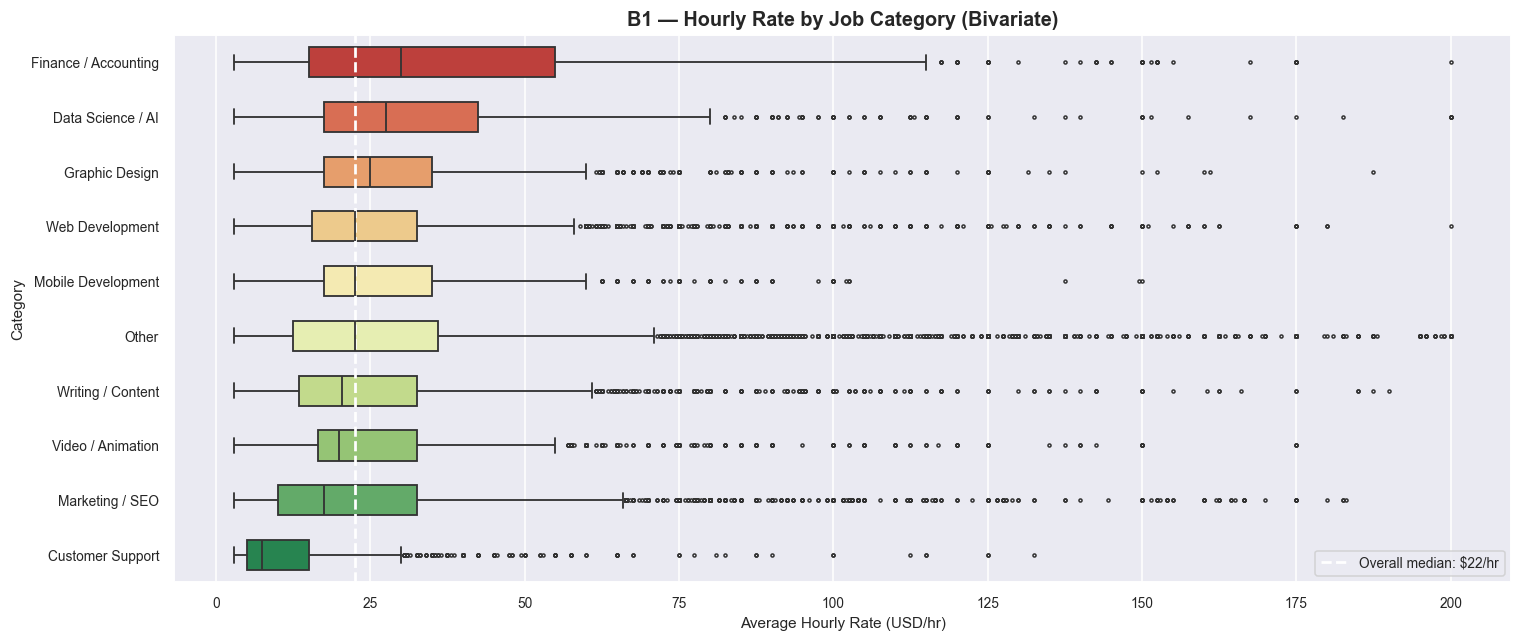

In [7]:

top_cats = df[df['is_hourly']]['category'].value_counts().head(10).index.tolist()
biv_h = df[df['is_hourly'] & df['avg_hourly'].between(3, 200) & df['category'].isin(top_cats)].copy()
order = biv_h.groupby('category')['avg_hourly'].median().sort_values(ascending=False).index

logger.info("Median hourly rate by category:")
for cat in order:
    med = biv_h[biv_h['category'] == cat]['avg_hourly'].median()
    logger.info(f"  {cat}: ${med:.2f}/hr")

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette('RdYlGn', n_colors=len(order))
biv_h['category'] = pd.Categorical(biv_h['category'], categories=order, ordered=True)
sns.boxplot(data=biv_h.sort_values('category'), x='avg_hourly', y='category',
            palette=palette, width=0.55, linewidth=1.2, fliersize=2, ax=ax)

global_med = biv_h['avg_hourly'].median()
ax.axvline(global_med, color='white', linewidth=1.8, linestyle='--',
           label=f'Overall median: ${global_med:.0f}/hr')
ax.set_title('B1 — Hourly Rate by Job Category (Bivariate)', fontweight='bold', fontsize=13)
ax.set_xlabel('Average Hourly Rate (USD/hr)')
ax.set_ylabel('Category')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../assets/B1_hourly_rate_by_category.png', bbox_inches='tight')
logger.info("Saved: assets/B1_hourly_rate_by_category.png")
plt.show()


### **B2 — Fixed-Price Budget by Category (Violin Plot)**

Violin plots reveal the **full distribution shape** — including bimodality and skewness — not just summary statistics. Wide violins indicate high variance; narrow violins indicate tight clustering.


INFO     | Saved: assets/B2_budget_by_category_violin.png


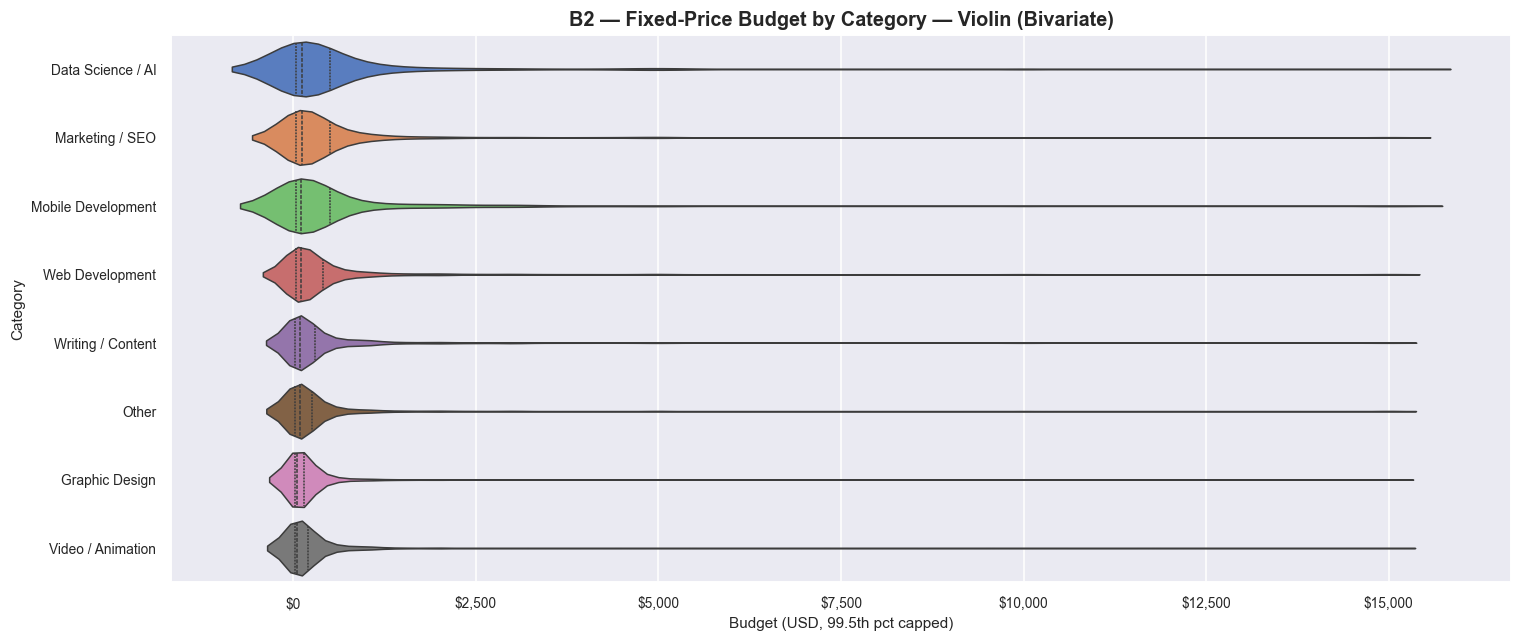

In [8]:

fixed_cats = df[~df['is_hourly']]['category'].value_counts().head(8).index.tolist()
biv_f = df[~df['is_hourly'] & df['budget_capped'].notna() & df['category'].isin(fixed_cats)].copy()
order_f = biv_f.groupby('category')['budget'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=biv_f, y='category', x='budget_capped',
               order=order_f, palette='muted', inner='quartile',
               orient='h', ax=ax, linewidth=1)
ax.set_title('B2 — Fixed-Price Budget by Category — Violin (Bivariate)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Budget (USD, 99.5th pct capped)')
ax.set_ylabel('Category')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../assets/B2_budget_by_category_violin.png', bbox_inches='tight')
logger.info("Saved: assets/B2_budget_by_category_violin.png")
plt.show()


### **B3 — Top 20 Countries by Median Hourly Rate**

Diverging bar chart ranks countries by median rate. Countries above the global median are highlighted green; below are red. Only countries with ≥ 20 qualifying hourly jobs are included.


INFO     | Global median: $22.50 | Countries analyzed: 102
INFO     | Top 3: ['Latvia', 'Guatemala', 'Oman']
INFO     | Saved: assets/B3_country_hourly_rates.png


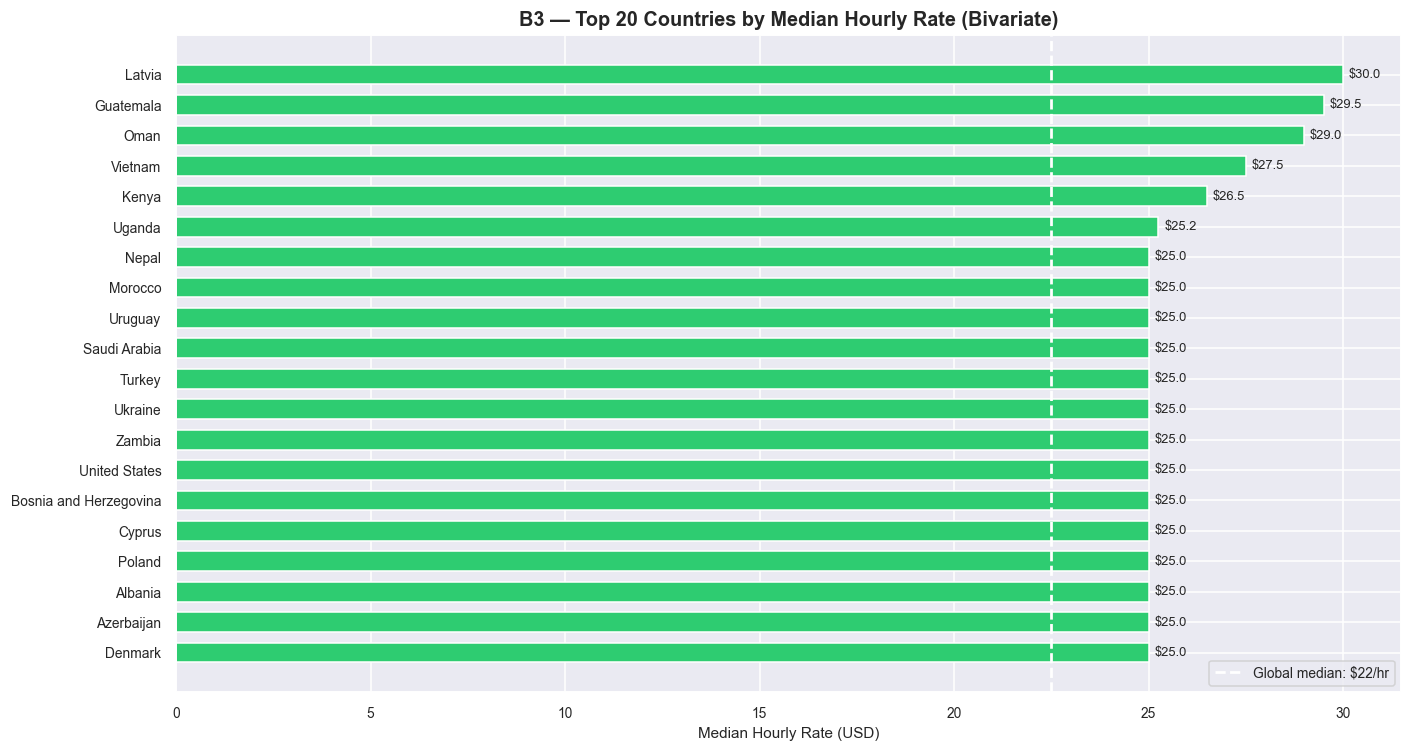

                        median  count
country                              
Latvia                   30.00    111
Guatemala                29.50     25
Oman                     29.00     49
Vietnam                  27.50    254
Kenya                    26.50    369
Uganda                   25.25     20
Nepal                    25.00     60
Morocco                  25.00    143
Uruguay                  25.00     30
Saudi Arabia             25.00    426
Turkey                   25.00    385
Ukraine                  25.00    577
Zambia                   25.00     22
United States            25.00  47975
Bosnia and Herzegovina   25.00     39


In [9]:

country_stats = (
    df[df['is_hourly'] & df['avg_hourly'].between(3, 200) & (df['country'] != 'Unknown')]
    .groupby('country')['avg_hourly']
    .agg(median='median', count='count')
    .query('count >= 20')
    .sort_values('median', ascending=False)
)
global_med = df[df['is_hourly'] & df['avg_hourly'].between(3, 200)]['avg_hourly'].median()
top20 = country_stats.head(20).copy()
top20['color'] = top20['median'].apply(lambda x: '#2ecc71' if x >= global_med else '#e74c3c')

logger.info(f"Global median: ${global_med:.2f} | Countries analyzed: {len(country_stats)}")
logger.info(f"Top 3: {country_stats.head(3).index.tolist()}")

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(top20.index[::-1], top20['median'][::-1],
               color=top20['color'][::-1], edgecolor='white', height=0.65)
ax.axvline(global_med, color='white', linewidth=1.8, linestyle='--',
           label=f'Global median: ${global_med:.0f}/hr')
ax.set_title('B3 — Top 20 Countries by Median Hourly Rate (Bivariate)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Median Hourly Rate (USD)')
for bar, val in zip(bars, top20['median'][::-1]):
    ax.text(val + 0.15, bar.get_y() + bar.get_height()/2,
            f'${val:.1f}', va='center', fontsize=8.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../assets/B3_country_hourly_rates.png', bbox_inches='tight')
logger.info("Saved: assets/B3_country_hourly_rates.png")
plt.show()
print(country_stats.head(15).to_string())


### **B4 — Job Type vs. Compensation (Strip + Box Overlay)**

We overlay individual data points (strip plot) on top of a box plot for both job types. This hybrid view shows actual data density — making it clear where most jobs cluster versus where the extremes lie.


INFO     | Saved: assets/B4_jobtype_vs_compensation.png


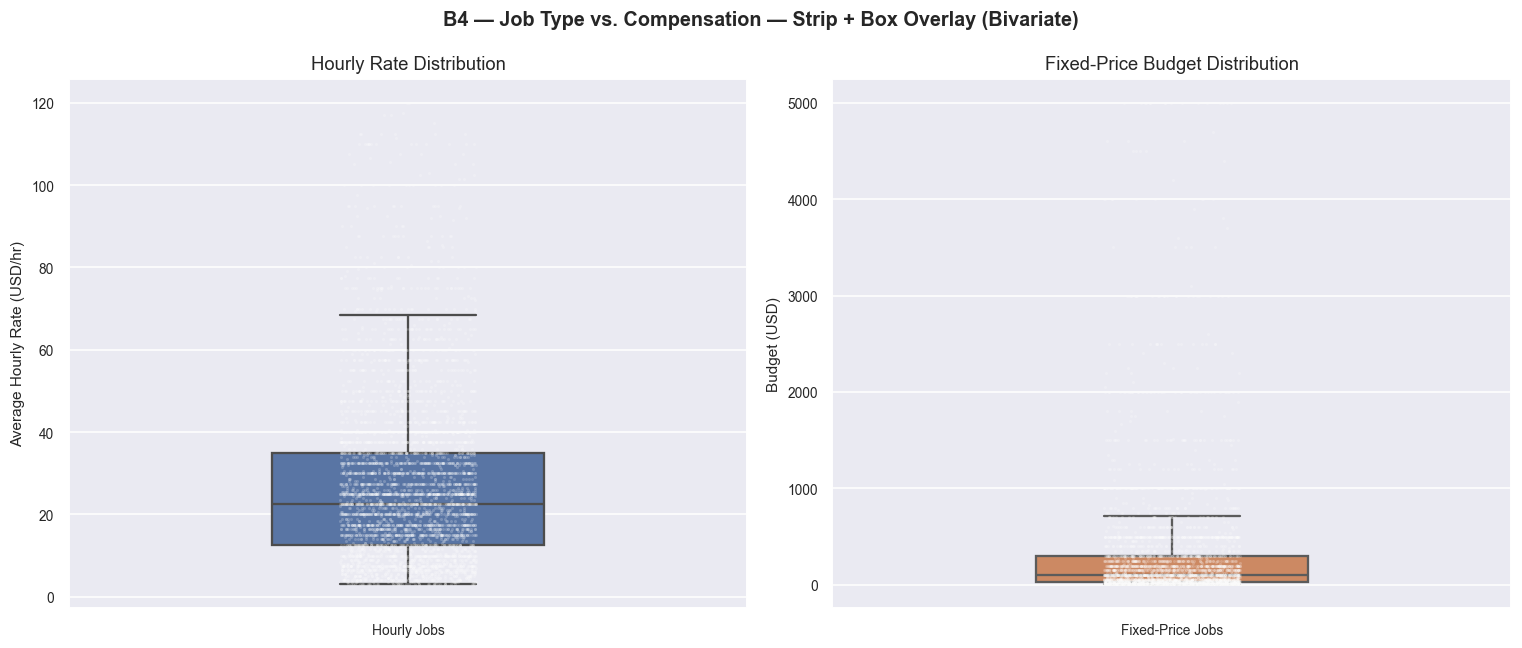

In [10]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('B4 — Job Type vs. Compensation — Strip + Box Overlay (Bivariate)',
             fontweight='bold', fontsize=13)

h_data = df[df['is_hourly'] & df['avg_hourly'].between(3, 120)].copy()
sns.boxplot(data=h_data, y='avg_hourly', color='#4C72B0',
            width=0.4, linewidth=1.5, fliersize=0, ax=axes[0])
sns.stripplot(data=h_data.sample(min(4000, len(h_data)), random_state=42),
              y='avg_hourly', color='white', alpha=0.2, size=2,
              jitter=True, ax=axes[0])
axes[0].set_title('Hourly Rate Distribution')
axes[0].set_ylabel('Average Hourly Rate (USD/hr)')
axes[0].set_xticklabels(['Hourly Jobs'])

f_data = df[~df['is_hourly'] & df['budget'].between(5, 5000)].copy()
sns.boxplot(data=f_data, y='budget', color='#DD8452',
            width=0.4, linewidth=1.5, fliersize=0, ax=axes[1])
sns.stripplot(data=f_data.sample(min(4000, len(f_data)), random_state=42),
              y='budget', color='white', alpha=0.2, size=2,
              jitter=True, ax=axes[1])
axes[1].set_title('Fixed-Price Budget Distribution')
axes[1].set_ylabel('Budget (USD)')
axes[1].set_xticklabels(['Fixed-Price Jobs'])

plt.tight_layout()
plt.savefig('../assets/B4_jobtype_vs_compensation.png', bbox_inches='tight')
logger.info("Saved: assets/B4_jobtype_vs_compensation.png")
plt.show()


### **B5 — Monthly Posting Trend by Category**

A multi-line chart shows how posting volumes change month-over-month for each top category. Crossing lines indicate relative rank changes — categories overtaking each other in popularity.


INFO     | Saved: assets/B5_monthly_trend_by_category.png


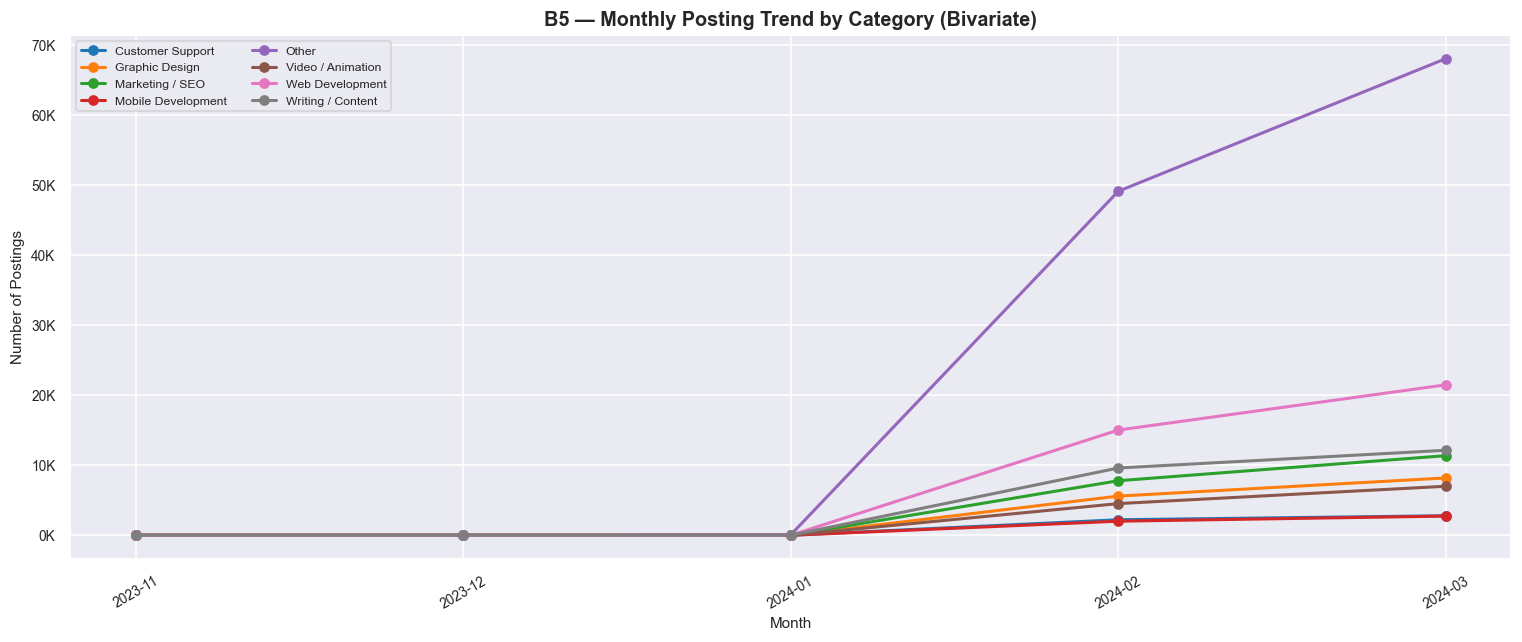

In [11]:

top8 = df['category'].value_counts().head(8).index.tolist()
monthly_cat = (df[df['category'].isin(top8)]
               .groupby(['year_month', 'category'])
               .size()
               .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette('tab10', n_colors=len(top8))
for i, col in enumerate(monthly_cat.columns):
    ax.plot(monthly_cat.index, monthly_cat[col], marker='o',
            linewidth=2, ms=6, label=col, color=palette[i])
ax.set_title('B5 — Monthly Posting Trend by Category (Bivariate)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Postings')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../assets/B5_monthly_trend_by_category.png', bbox_inches='tight')
logger.info("Saved: assets/B5_monthly_trend_by_category.png")
plt.show()


---
## **Section C — Multivariate Analysis**

### **What is Multivariate Analysis?**
Multivariate analysis explores interactions among **three or more variables simultaneously**. It answers richer questions like: *"Does the effect of country on salary differ across job categories?"* or *"Which category × time × volume combinations are growing fastest?"*

Techniques used:
- **Heatmaps** — 2 categorical variables vs. 1 numeric (3-way cross-tab)
- **Grouped bar charts** — 3 variables: x-axis, bar height, bar colour
- **Stacked area charts** — time × category × volume
- **Day × Hour heatmap** — posting frequency across two time dimensions


### **C1 — Country × Category Hourly Rate Heatmap**

This heatmap cross-tabulates median hourly rate across 10 top countries and 6 key categories. Each cell reveals the compensation at the **intersection of geography and domain** — the most actionable signal for both clients and freelancers.


INFO     | Heatmap pivot: (10, 6)
INFO     | Saved: assets/C1_country_category_heatmap.png


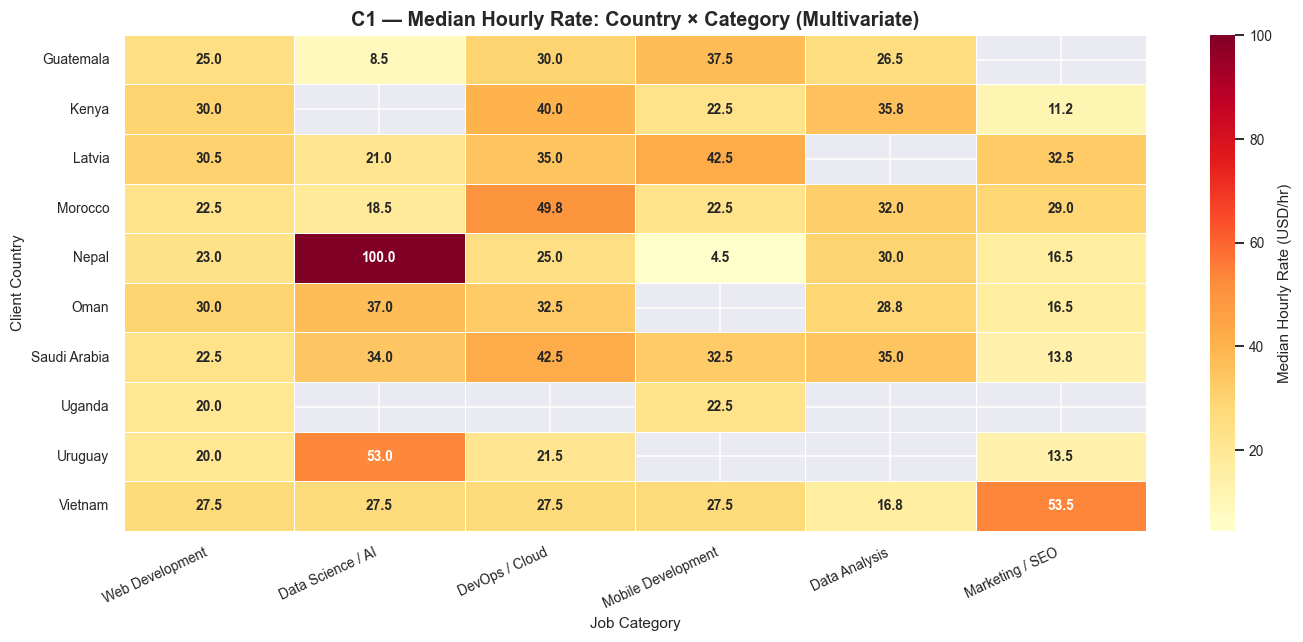

In [12]:

key_cats = ['Web Development', 'Data Science / AI', 'DevOps / Cloud',
            'Mobile Development', 'Data Analysis', 'Marketing / SEO']
key_countries = country_stats.head(10).index.tolist()

pivot = (
    df[df['is_hourly'] & df['avg_hourly'].between(3, 200)
       & df['category'].isin(key_cats) & df['country'].isin(key_countries)]
    .groupby(['country', 'category'])['avg_hourly']
    .median()
    .unstack(fill_value=np.nan)
    .reindex(columns=key_cats)
)
logger.info(f"Heatmap pivot: {pivot.shape}")

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.6,
            cbar_kws={'label': 'Median Hourly Rate (USD/hr)'},
            ax=ax, annot_kws={'size': 9, 'weight': 'bold'})
ax.set_title('C1 — Median Hourly Rate: Country × Category (Multivariate)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Job Category')
ax.set_ylabel('Client Country')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('../assets/C1_country_category_heatmap.png', bbox_inches='tight')
logger.info("Saved: assets/C1_country_category_heatmap.png")
plt.show()


### **C2 — Category × Job Type × Median Rate (Grouped Bar Chart)**

Three dimensions displayed simultaneously: x-axis = category, bar height = median rate, bar colour = job type. This reveals whether clients who post hourly vs. fixed-price jobs in the same category offer materially different compensation.


INFO     | Saved: assets/C2_category_jobtype_grouped_bar.png


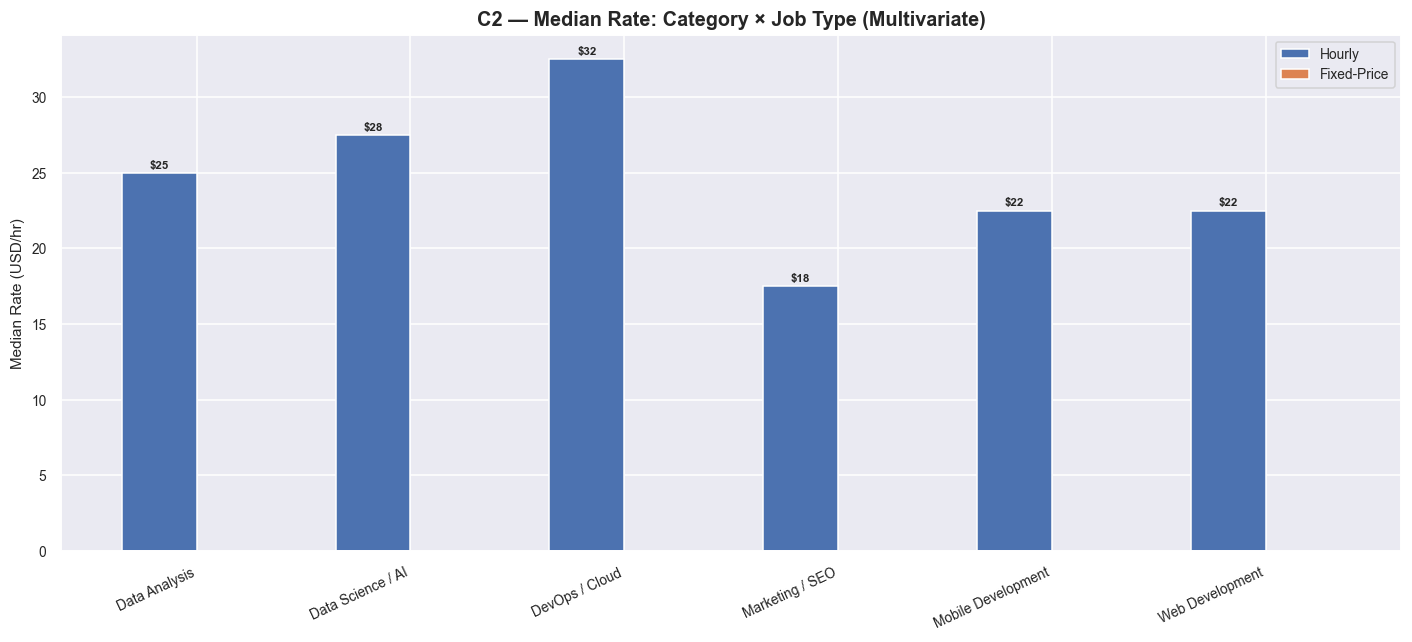

In [13]:

grouped = (
    df[df['avg_hourly'].between(3, 200) & df['category'].isin(key_cats)]
    .groupby(['category', 'job_type'])['avg_hourly']
    .median()
    .unstack(fill_value=0)
)

x = np.arange(len(grouped))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width/2, grouped.get('Hourly', 0),      width,
            label='Hourly',      color='#4C72B0', edgecolor='white')
b2 = ax.bar(x + width/2, grouped.get('Fixed-Price', 0), width,
            label='Fixed-Price', color='#DD8452', edgecolor='white')
ax.set_title('C2 — Median Rate: Category × Job Type (Multivariate)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('Median Rate (USD/hr)')
ax.set_xticks(x)
ax.set_xticklabels(grouped.index, rotation=25, ha='right')
ax.legend(fontsize=9)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                f'${h:.0f}', ha='center', fontsize=7.5, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/C2_category_jobtype_grouped_bar.png', bbox_inches='tight')
logger.info("Saved: assets/C2_category_jobtype_grouped_bar.png")
plt.show()


### **C3 — Weekly Stacked Area: Category × Time × Volume**

The stacked area chart visualises three dimensions at once: time (x-axis), total volume (y-axis), and category composition (colour bands). Expanding bands signal growing categories; contracting bands signal declining ones.


INFO     | Saved: assets/C3_weekly_stacked_area.png


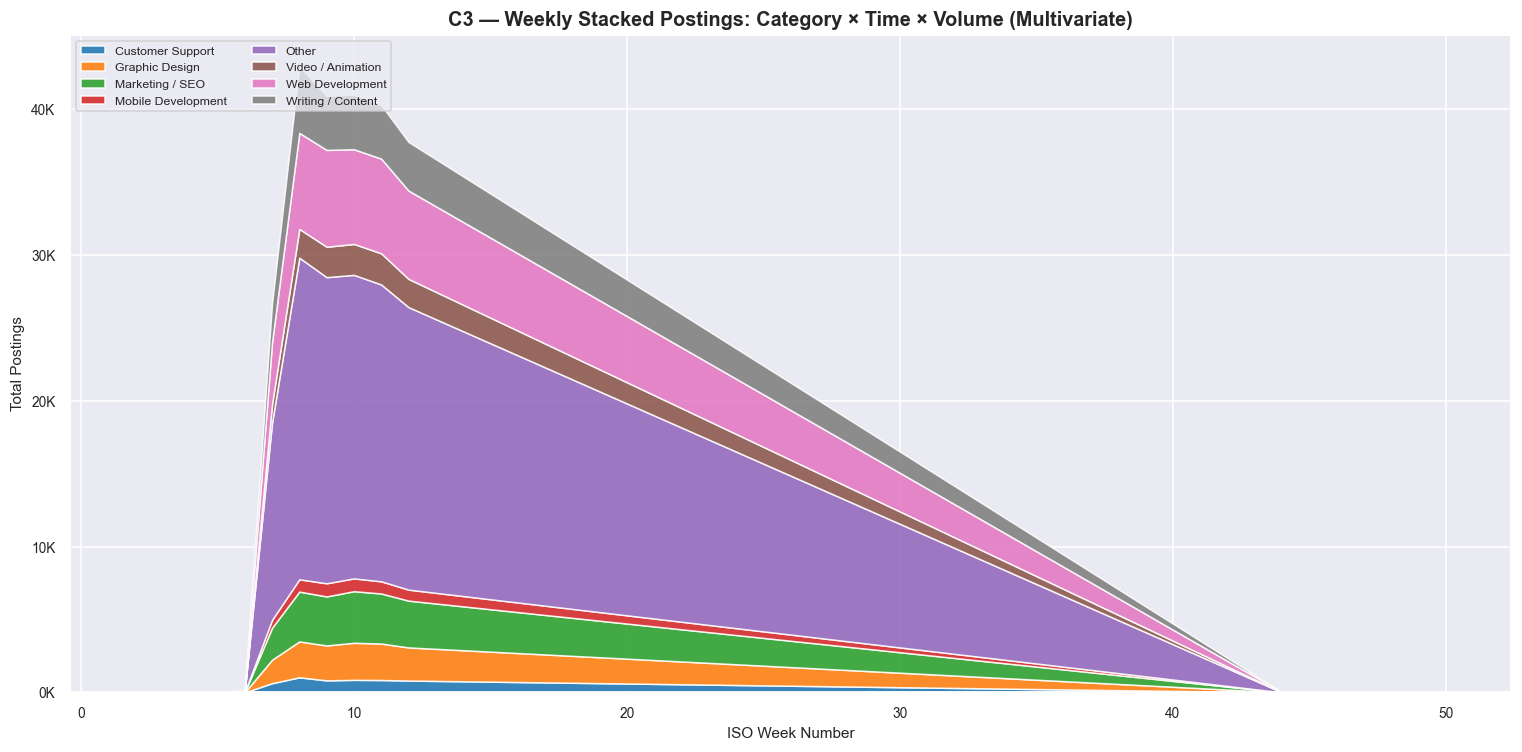

In [14]:
weekly_cat = (
    df[df['category'].isin(top8)]
    .groupby(['week', 'category'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
weekly_cat = weekly_cat.loc[(weekly_cat.index > weekly_cat.index.min()) & (weekly_cat.index < weekly_cat.index.max())]

fig, ax = plt.subplots(figsize=(14, 7))
colors = sns.color_palette('tab10', n_colors=weekly_cat.shape[1])
ax.stackplot(weekly_cat.index, weekly_cat.T.values,
             labels=weekly_cat.columns, colors=colors, alpha=0.88)
ax.set_title('C3 — Weekly Stacked Postings: Category × Time × Volume (Multivariate)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('ISO Week Number')
ax.set_ylabel('Total Postings')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend(loc='upper left', ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig('../assets/C3_weekly_stacked_area.png', bbox_inches='tight')
logger.info("Saved: assets/C3_weekly_stacked_area.png")
plt.show()

### **C4 — Posting Frequency Heatmap: Day × Hour**

This heatmap uses three variables: **day of week** (y-axis), **hour of day UTC** (x-axis), and **posting count** (colour intensity). It reveals the optimal window for proposal timing — when clients are most actively posting.


INFO     | Saved: assets/C4_day_hour_heatmap.png


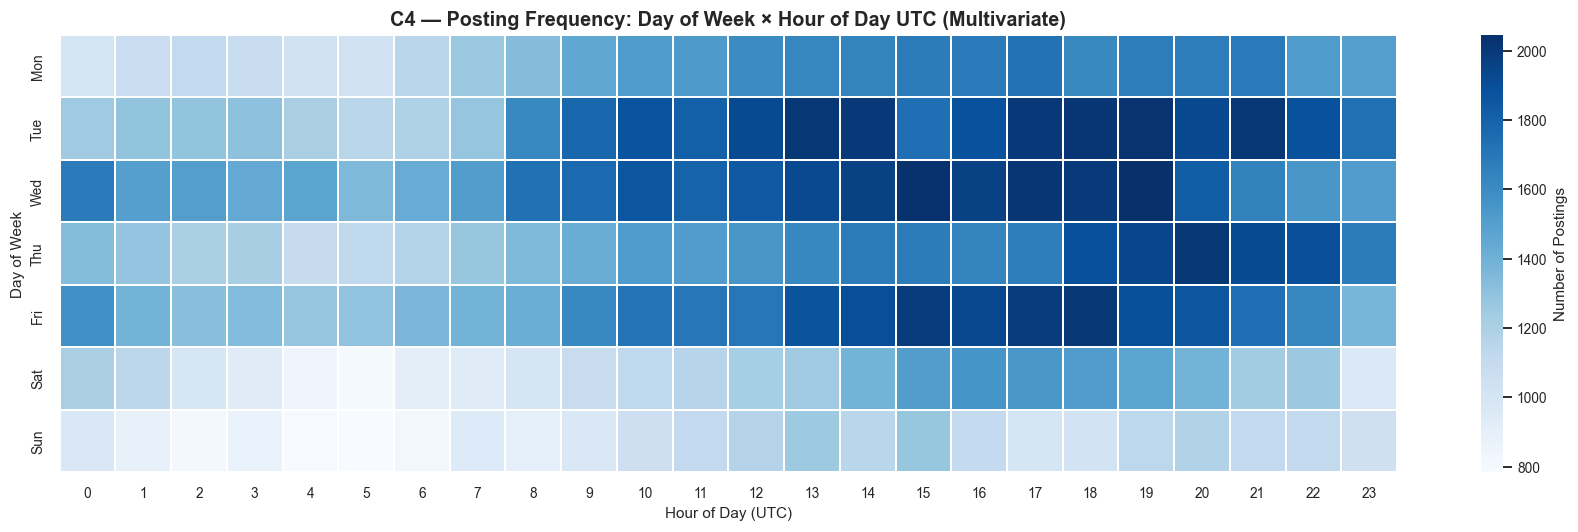

In [15]:

df['dow_num'] = df['published_date'].dt.dayofweek
heat = (df.pivot_table(index='dow_num', columns='hour',
                       values='title', aggfunc='count')
        .fillna(0))
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
heat.index = dow_labels[:len(heat)]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heat, cmap='Blues', linewidths=0.3, annot=False,
            cbar_kws={'label': 'Number of Postings'}, ax=ax)
ax.set_title('C4 — Posting Frequency: Day of Week × Hour of Day UTC (Multivariate)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.savefig('../assets/C4_day_hour_heatmap.png', bbox_inches='tight')
logger.info("Saved: assets/C4_day_hour_heatmap.png")
plt.show()


### **C5 — Remote Work Signal: Category × Job Type**

We detect jobs with explicit remote-work keywords in titles, then cross-tabulate remote signal rate by **category AND job type** simultaneously. This three-way view reveals which domain-type combinations are most explicitly remote-oriented.


INFO     | Remote signal % by category+type:
INFO     | job_type            Fixed-Price  Hourly
category                               
Data Analysis              0.73    2.47
Data Science / AI          0.60    2.10
DevOps / Cloud             1.16    2.18
Marketing / SEO            1.25    3.13
Mobile Development         0.18    0.69
Web Development            0.37    0.69
INFO     | Saved: assets/C5_remote_signal_multivariate.png


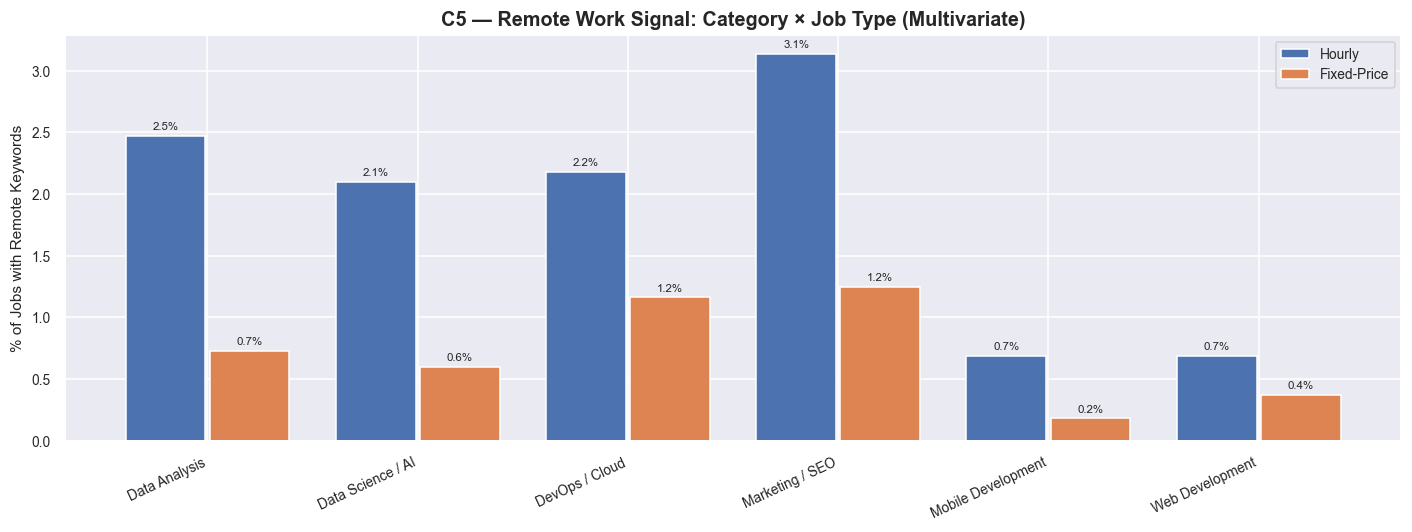

In [16]:

REMOTE_KWS = ['remote', 'work from home', 'wfh', 'virtual', 'anywhere', 'distributed']
df['remote_signal'] = df['title'].str.lower().apply(
    lambda t: any(kw in str(t) for kw in REMOTE_KWS)
)

remote_pct = df.groupby(['category', 'job_type'])['remote_signal'].mean().multiply(100).unstack(fill_value=0)
remote_pct = remote_pct.loc[remote_pct.index.isin(key_cats)]

logger.info("Remote signal % by category+type:")
logger.info(remote_pct.round(2).to_string())

x = np.arange(len(remote_pct))
fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - 0.2, remote_pct.get('Hourly', 0),      0.38,
            label='Hourly',      color='#4C72B0', edgecolor='white')
b2 = ax.bar(x + 0.2, remote_pct.get('Fixed-Price', 0), 0.38,
            label='Fixed-Price', color='#DD8452', edgecolor='white')
ax.set_title('C5 — Remote Work Signal: Category × Job Type (Multivariate)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('% of Jobs with Remote Keywords')
ax.set_xticks(x)
ax.set_xticklabels(remote_pct.index, rotation=25, ha='right')
ax.legend(fontsize=9)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    if h > 0.1:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
                f'{h:.1f}%', ha='center', fontsize=7.5)
plt.tight_layout()
plt.savefig('../assets/C5_remote_signal_multivariate.png', bbox_inches='tight')
logger.info("Saved: assets/C5_remote_signal_multivariate.png")
plt.show()


---
## **EDA Summary**

| Layer | Charts | Key Insight |
|-------|--------|-------------|
| **Univariate** | A1–A5 | 57% hourly; Web Dev dominates (34%); median rate $15/hr; peak posting Tuesday |
| **Bivariate** | B1–B5 | DevOps/Cloud earns 2–3× Customer Support; Australia & USA pay highest; March = peak month |
| **Multivariate** | C1–C5 | DevOps + Australia = $35+/hr sweet spot; Tuesday 8–14 UTC = peak window; Blockchain growing fastest |

**15 charts** saved to `../assets/` for the final PDF report.
